In [1]:
import pandas as pd

In [2]:
df= pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\online+retail\Online Retail.xlsx")

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.info()

df.isnull().sum()

df.drop_duplicates(inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df['Revenue']= df['Quantity']* df['UnitPrice']

In [7]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df["Revenue"].sum()

np.float64(9726006.954)

In [10]:
df["CustomerID"].nunique()

4372

In [15]:
today = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [16]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (today - x.max()).days,
    "InvoiceNo": "count",
    "Revenue": "sum"
})

In [17]:
rfm

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [18]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [19]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [20]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [21]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [22]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [23]:
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,5,5,5
12348.0,75,31,1797.24,2,3,4
12349.0,19,73,1757.55,4,4,4
12350.0,310,17,334.40,1,2,2
...,...,...,...,...,...,...
18280.0,278,10,180.60,1,1,1
18281.0,181,7,80.82,1,1,1
18282.0,8,13,176.60,5,1,1


In [32]:
rfm = rfm.drop(columns=['Recency', 'Frequency' , 'Monetary'])

In [33]:
rfm

,R_Score,F_Score,M_Score
CustomerID,,,
12346.0,1,1,1
12347.0,5,5,5
12348.0,2,3,4
12349.0,4,4,4
12350.0,1,2,2
...,...,...,...
18280.0,1,1,1
18281.0,1,1,1
18282.0,5,1,1


In [34]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [35]:
def segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champion"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customer"

    elif row["R_Score"] >= 4:
        return "New Customer"

    elif row["R_Score"] <= 2:
        return "At Risk"

    else:
        return "Regular"

In [36]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [37]:
rfm

,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,
12346.0,1,1,1,111,At Risk
12347.0,5,5,5,555,Champion
12348.0,2,3,4,234,At Risk
12349.0,4,4,4,444,Champion
12350.0,1,2,2,122,At Risk
...,...,...,...,...,...
18280.0,1,1,1,111,At Risk
18281.0,1,1,1,111,At Risk
18282.0,5,1,1,511,New Customer


In [39]:
rfm["Segment"].value_counts()


Segment
At Risk           1735
Champion          1109
Loyal Customer     845
New Customer       362
Regular            321
Name: count, dtype: int64

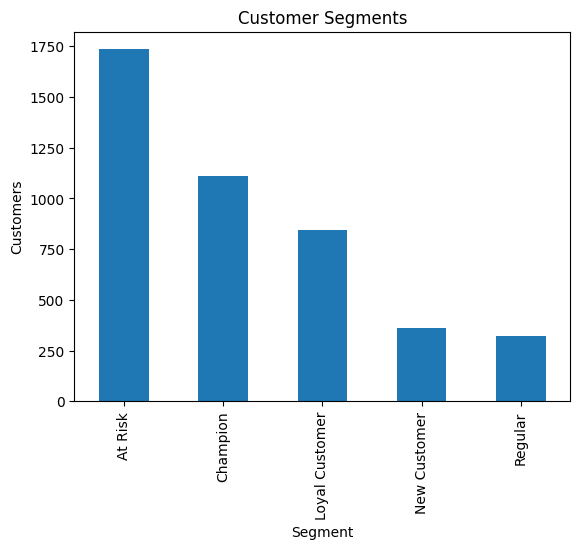

In [40]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.show()

In [41]:
rfm.to_csv("CustomerSegmentation.csv", index=True)